In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

# Load the Data

In [2]:
df = pd.read_csv("House Price Prediction Dataset.csv")

In [3]:
df.head().style.background_gradient(cmap = "PuBu")

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


# Understand the Dataset

In [4]:
from colorama import Fore, Style

print("The shape of the dataframe (number of rows and columns)")
print(Fore.CYAN + "df shape: " + Style.RESET_ALL)
print(f"{df.shape}\n")

print("Basic information about the dataframe (column names, data types, non-null values)")
print(Fore.GREEN + "df info: " + Style.RESET_ALL)
print(f"{df.info()}\n") 

print("The count of missing (NaN) values in each column")
print(Fore.YELLOW + "df isnull sum: " + Style.RESET_ALL)
print(f"{df.isnull().sum()}\n")

print("Summary statistics for numerical columns (count, mean, std, min, max, etc.)")
print(Fore.MAGENTA + "df describe: " + Style.RESET_ALL)
print(f"{df.describe()}\n")

The shape of the dataframe (number of rows and columns)
df shape: 
(2000, 10)

Basic information about the dataframe (column names, data types, non-null values)
df info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
None

The count of missing (NaN) values in each column
df isnull sum: 
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage     

# Finding outliers

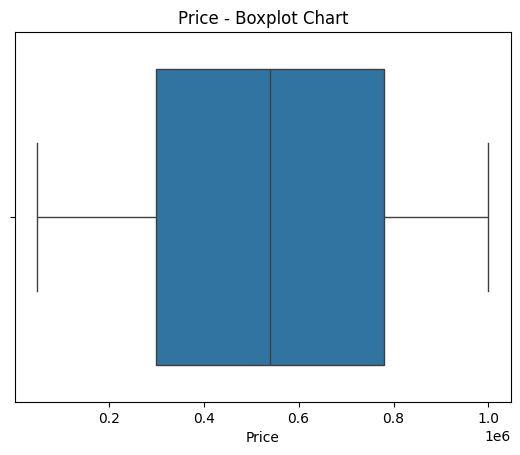

Outliers - Z-Score:
 Empty DataFrame
Columns: [Area, Price, YearBuilt]
Index: []


In [5]:
sns.boxplot(data=df, x='Price')       
plt.title('Price - Boxplot Chart')
plt.show()

df_num = df[['Area', 'Price', 'YearBuilt']] 

z_scores = np.abs(stats.zscore(df_num)) 

threshold = 2.57
outliers_zscore = df_num[(z_scores > threshold).any(axis=1)]
print("Outliers - Z-Score:\n", outliers_zscore)

# Preprocessing Data

In [6]:
location_avg_price = df.groupby('Location')['Price'].transform('mean')
df['Location_ratio'] = df['Price'] / location_avg_price
    
df['Condition'] = df['Condition'].map({'Excellent': 1, 'Fair': 2, 'Good': 3, 'Poor': 4})
df['Location'] = df['Location'].map({'Downtown': 1, 'Rural': 2, 'Suburban': 3, 'Urban': 4})
df['Garage'] = df['Garage'].map({'Yes': 1, 'No': 0})

# Save the preprocessed data

In [7]:
df.to_csv("Preprocessed_data.csv", index=False)